In [1]:
# Import required libraries for data analysis,
# visualization, and machine learning
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

In [2]:
# Load the Housing dataset from CSV file
df = pd.read_csv("Housing.csv")

print("Dataset Loaded Successfully!")

Dataset Loaded Successfully!


In [3]:
# Display the first 10 rows of the dataset
df.head(10)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
5,10850000,7500,3,3,1,yes,no,yes,no,yes,2,yes,semi-furnished
6,10150000,8580,4,3,4,yes,no,no,no,yes,2,yes,semi-furnished
7,10150000,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished
8,9870000,8100,4,1,2,yes,yes,yes,no,yes,2,yes,furnished
9,9800000,5750,3,2,4,yes,yes,no,no,yes,1,yes,unfurnished


In [4]:
# Display the total number of rows and columns
print("Rows and Columns:", df.shape)

Rows and Columns: (545, 13)


In [5]:
# Identify target variable and feature variables
target = "price"

features = df.drop("price", axis=1)

print("Target Column:", target)

print("\nFeature Columns:")
print(features.columns.tolist())

Target Column: price

Feature Columns:
['area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea', 'furnishingstatus']


In [6]:
# Check for missing values in each column
df.isnull().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

In [7]:
# Check the dataset for duplicate records
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [8]:
# Remove duplicate records if present
df = df.drop_duplicates()

print("New Shape:", df.shape)

New Shape: (545, 13)


In [9]:
# Convert categorical variables into numerical format
# using one-hot encoding
df = pd.get_dummies(df, drop_first=True)

df.head()

,price,area,bedrooms,bathrooms,stories,parking,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,2,True,False,False,False,True,True,False,False
1,12250000,8960,4,4,4,3,True,False,False,False,True,False,False,False
2,12250000,9960,3,2,2,2,True,False,True,False,False,True,True,False
3,12215000,7500,4,2,2,3,True,False,True,False,True,True,False,False
4,11410000,7420,4,1,2,2,True,True,True,False,True,False,False,False


In [10]:
# Display dataset information after preprocessing
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 14 columns):
 #   Column                           Non-Null Count  Dtype
---  ------                           --------------  -----
 0   price                            545 non-null    int64
 1   area                             545 non-null    int64
 2   bedrooms                         545 non-null    int64
 3   bathrooms                        545 non-null    int64
 4   stories                          545 non-null    int64
 5   parking                          545 non-null    int64
 6   mainroad_yes                     545 non-null    bool 
 7   guestroom_yes                    545 non-null    bool 
 8   basement_yes                     545 non-null    bool 
 9   hotwaterheating_yes              545 non-null    bool 
 10  airconditioning_yes              545 non-null    bool 
 11  prefarea_yes                     545 non-null    bool 
 12  furnishingstatus_semi-furnished  545 non-null    b

In [11]:
# Import machine learning models and evaluation metrics
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [12]:
# Separate input features (X) and target variable (y)
X = df.drop("price", axis=1)

y = df["price"]

print("X Shape:", X.shape)
print("y Shape:", y.shape)

X Shape: (545, 13)
y Shape: (545,)


In [13]:
# Split dataset into training and testing sets
# using an 80:20 ratio
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training Samples:", len(X_train))
print("Testing Samples:", len(X_test))

Training Samples: 436
Testing Samples: 109


In [14]:
# Create and train Linear Regression model
lr = LinearRegression()

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

In [15]:
# Evaluate Linear Regression model performance
# using MAE, RMSE, and R² score
lr_mae = mean_absolute_error(y_test, lr_pred)

lr_rmse = mean_squared_error(y_test, lr_pred) ** 0.5

lr_r2 = r2_score(y_test, lr_pred)

print("Linear Regression Results")
print("-------------------------")
print("MAE :", lr_mae)
print("RMSE:", lr_rmse)
print("R2 :", lr_r2)

Linear Regression Results
-------------------------
MAE : 970043.4039201637
RMSE: 1324506.9600914388
R2 : 0.6529242642153184


In [16]:
# Create and train Random Forest Regressor model
rf = RandomForestRegressor(
    n_estimators=500,
    max_depth=10,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

In [17]:
# Evaluate Random Forest model performance
# using MAE, RMSE, and R² score
rf_mae = mean_absolute_error(y_test, rf_pred)

rf_rmse = mean_squared_error(y_test, rf_pred) ** 0.5

rf_r2 = r2_score(y_test, rf_pred)

print("Random Forest Results")
print("-------------------------")
print("MAE :", rf_mae)
print("RMSE:", rf_rmse)
print("R2 :", rf_r2)

Random Forest Results
-------------------------
MAE : 1015682.9111609888
RMSE: 1393448.0489554584
R2 : 0.6158531051109299


In [18]:
# Compare the performance of both regression models
comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "MAE": [lr_mae, rf_mae],
    "RMSE": [lr_rmse, rf_rmse],
    "R2 Score": [lr_r2, rf_r2]
})

comparison

,Model,MAE,RMSE,R2 Score
0,Linear Regression,9.700434e+05,1.324507e+06,0.652924
1,Random Forest,1.015683e+06,1.393448e+06,0.615853


In [19]:
# Create charts folder for storing visualizations
import os

os.makedirs("charts", exist_ok=True)

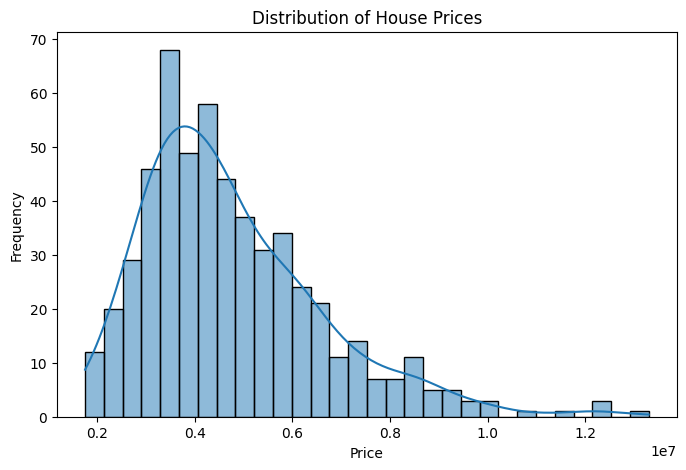

In [20]:
# Plot distribution of house prices using a histogram
plt.figure(figsize=(8,5))

sns.histplot(df["price"], bins=30, kde=True)

plt.title("Distribution of House Prices")
plt.xlabel("Price")
plt.ylabel("Frequency")

plt.savefig("charts/price_distribution.png")

plt.show()

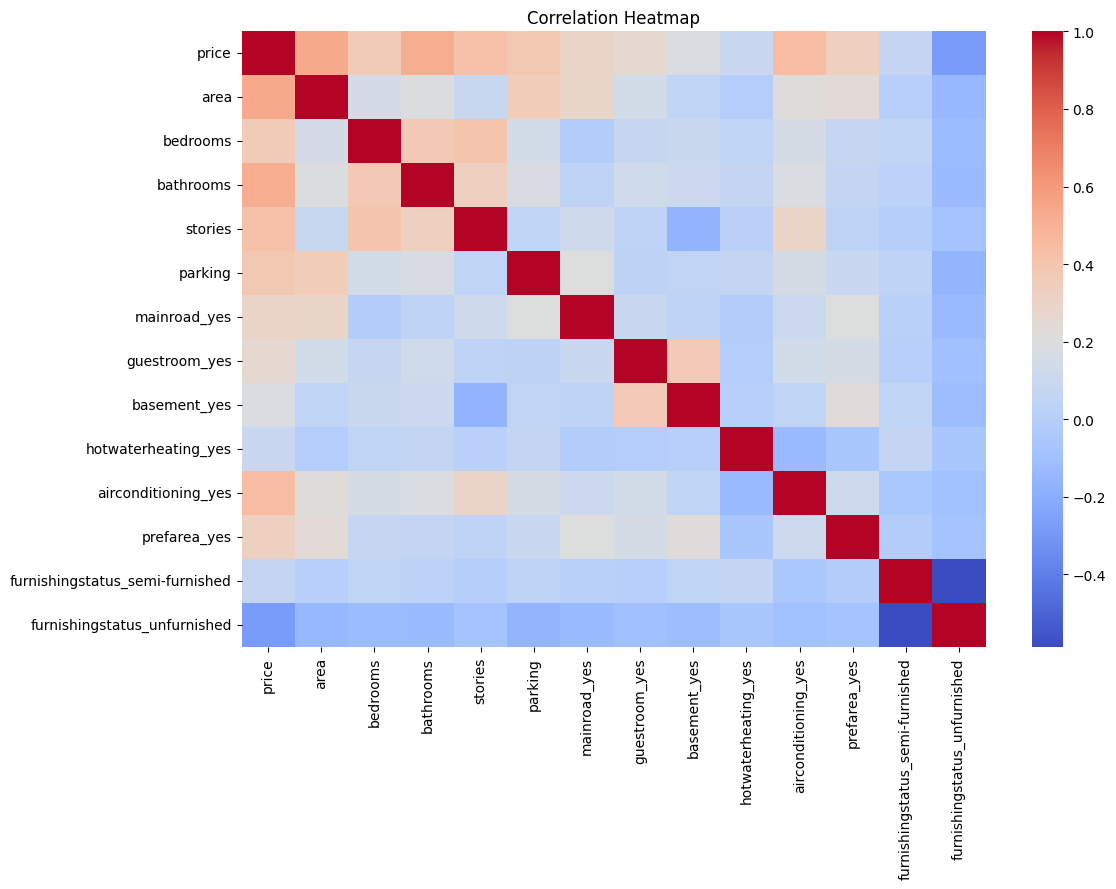

In [21]:
# Generate correlation heatmap to analyze feature relationships
plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(),
    cmap="coolwarm",
    annot=False
)

plt.title("Correlation Heatmap")

plt.savefig("charts/correlation_heatmap.png")

plt.show()

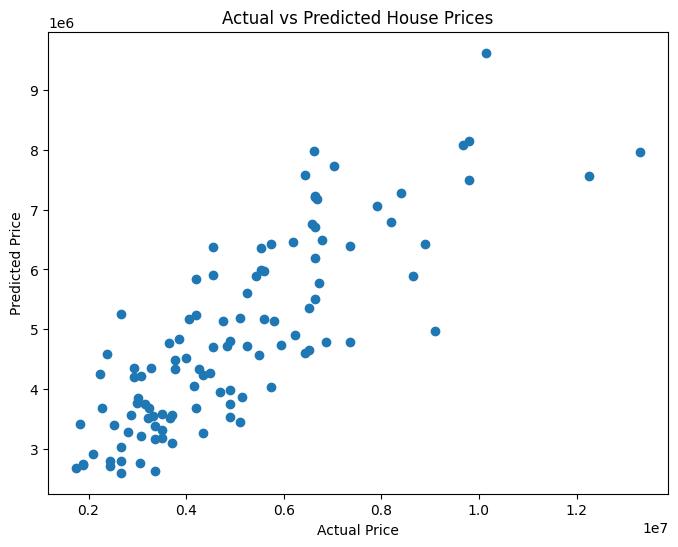

In [22]:
# Plot actual house prices against predicted house prices
plt.figure(figsize=(8,6))

plt.scatter(y_test, lr_pred)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")

plt.title("Actual vs Predicted House Prices")

plt.savefig("charts/actual_vs_predicted.png")

plt.show()

In [23]:
# Analyze feature importance using Linear Regression coefficients
importance = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": lr.coef_
})

importance["Abs_Coefficient"] = abs(
    importance["Coefficient"]
)

importance = importance.sort_values(
    by="Abs_Coefficient",
    ascending=False
)

importance.head(10)

,Feature,Coefficient,Abs_Coefficient
2,bathrooms,1.094445e+06,1.094445e+06
9,airconditioning_yes,7.914267e+05,7.914267e+05
8,hotwaterheating_yes,6.846499e+05,6.846499e+05
10,prefarea_yes,6.298906e+05,6.298906e+05
12,furnishingstatus_unfurnished,-4.136451e+05,4.136451e+05
3,stories,4.074766e+05,4.074766e+05
7,basement_yes,3.902512e+05,3.902512e+05
5,mainroad_yes,3.679199e+05,3.679199e+05
6,guestroom_yes,2.316100e+05,2.316100e+05
4,parking,2.248419e+05,2.248419e+05


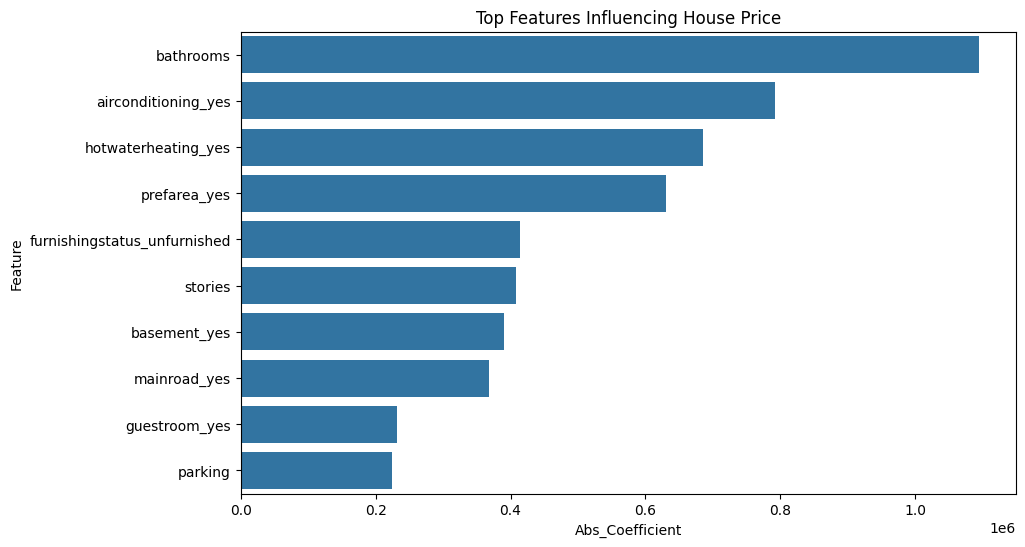

In [24]:
# Visualize the top features influencing house prices
plt.figure(figsize=(10,6))

sns.barplot(
    data=importance.head(10),
    x="Abs_Coefficient",
    y="Feature"
)

plt.title("Top Features Influencing House Price")

plt.show()

## Insights & Findings

The objective of this project was to predict house prices using machine learning techniques. Two regression models, Linear Regression and Random Forest Regressor, were trained and evaluated on the Housing dataset. Linear Regression performed better than Random Forest, achieving an R² score of approximately 0.65. Feature analysis showed that bathrooms, air conditioning, hot water heating, preferred area, and number of stories had the strongest influence on house prices. Based on these findings, real estate businesses should emphasize premium amenities and larger living spaces when marketing properties.

## Conclusion

A machine learning-based house price prediction system was successfully developed using the Housing Prices dataset. After preprocessing and encoding categorical variables, both Linear Regression and Random Forest models were trained and evaluated. Linear Regression achieved the best performance with an R² score of 0.653, MAE of approximately 970,043, and RMSE of approximately 1,324,507. The results indicate that house price is strongly influenced by factors such as bathrooms, air conditioning, hot water heating, preferred area, and number of stories. The developed model can assist buyers, sellers, and real estate businesses in estimating property values more effectively.